# 2.4 — Обучение DPI-EVT

**Папка 2 «Обучение», подноутбук 4.** DPI-EVT — гибрид: энкодер DPI-Flow выводит латент θ, из
которого строится **развязанная (decoupled)** граница CRR и траектория PPR(N), а число циклов
до разжижения берётся **из самой кривой PPR** (`nliq_from_curve=True`). Это делает модель
согласованным источником PPR, CRR, риска и N_liq без утверждений о лидерстве внутри training notebook.
Актуальные места моделей определяются только в `results/tables/*.csv`, которые пересчитывает серия `3_*`.

Раньше DPI-EVT обучался отдельным скриптом `run_dpievt.py` и не имел своего ноутбука — из-за
чего при чистой папке `models/` он терял веса и выпадал из оценки. Этот ноутбук **штатно**
обучает, калибрует и сохраняет DPI-EVT, повторяя ту же процедуру:

* фиксированный seed, **косинусный планировщик LR** (`scheduler="cosine"`) — ключ к качеству;
* развязанная CRR + N_liq из кривой, без traj-residual и без внутренней калибровки θ;
* пост-hoc калибровка ширины интервалов (`fit_interval_scale`).

> Важно: качество DPI-EVT чувствительно к косинусному расписанию LR — обычный прогон
> `train_model` без планировщика заметно его ухудшает.


## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch
from liquefaction_ai import (get_default_config, load_population_artifact,
                             prepare_benchmark_dataset, train_model, set_global_seed)
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, fit_interval_scale
from liquefaction_ai.models import DPIEvtNet

config = get_default_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
population, config = load_population_artifact(DATA_DIR)
benchmark = prepare_benchmark_dataset(population, config, device)
train, val, test = benchmark["train"], benchmark["val"], benchmark["test"]
static_dim = train["static"].shape[1]; prefix_dim = train["prefix_summary"].shape[1]
seq_dim = train["seq_in"].shape[-1]
print("Источник:", DATA_DIR.name, "| train/val/test:",
      train["static"].shape[0], val["static"].shape[0], test["static"].shape[0],
      "| static_dim:", static_dim)

Источник: dataset | train/val/test: 479 118 229 | static_dim: 38


## Шаг 1. Конфигурация и сборка модели

Параметры DPI-EVT соответствуют рабочей конфигурации: развязанная CRR, N_liq из кривой,
вероятностная голова и flow, без traj-residual и без внутренней калибровки θ.

**Порог разжижения.** `liq_threshold` берётся из общего конфига (`config.liq_threshold`) и
сохраняется в `models/dpi_evt/hyperparams.json`, поэтому training notebook, модельный артефакт
и оценка используют один и тот же порог. В текущем артефакте это `0.95`; итоговые значения
N_liq, CRR, Brier и CRPS не фиксируются в тексте ноутбука, а читаются из таблиц серии `3_*`.


In [2]:
MC_SOTA = False   # #3: включить MC-mixture обучение неопределённости DPI-EVT
SELECTION_METRIC = "Traj_RMSE"   # метрика отбора лучшей комбинации
fixed = dict(
    static_dim=static_dim, prefix_dim=prefix_dim, seq_dim=seq_dim,
    seq_len=config.seq_len, prefix_len=config.prefix_len,
    max_cycle_reference=config.max_cycle_reference,
    probabilistic=True, use_flow=False,                 # поток дестабилизирует EVT-движок
    nliq_from_curve=True, liq_threshold=config.liq_threshold,
    use_traj_residual=False,
    # MC-микстура (#3): калибрует разброс гауссова постериора под предиктивную ошибку
    # (mixture-NLL + energy-CRPS). MC_SOTA=False → прежнее поведение. use_flow остаётся False.
    **(dict(mc_train_samples=4, mc_crps_weight=0.3) if (globals().get('MC_SOTA', False)) else dict()),
)
# Разнообразный грид DPI-EVT: ёмкость энкодера × способ построения отчётной CRR × глубина
# дифференцируемой калибровки θ по префиксу. crr_mode — ключевая ось проекта (decoupled снимает
# компромисс «траектория↔CRR», hybrid/damage — альтернативы).
grid = {"hidden_dim": [128, 160, 192],
        "crr_mode": ["decoupled", "hybrid", "damage"],
        "calibration_steps": [0, 1]}
res, best = grid_search(lambda p: DPIEvtNet(**fixed, **p), grid, train, val,
                        config, device, search_epochs=config.grid_search_epochs,
                        score_metric=SELECTION_METRIC)
print("Selection metric:", SELECTION_METRIC, "| best:", best)
display(res.head(8))

model_kwargs = {**fixed, **best}
EPOCHS = config.publication_physics_epochs
set_global_seed(config.seed)          # единый сид проекта (детерминированная инициализация)
model = DPIEvtNet(**model_kwargs).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("DPI-EVT параметров:", f"{n_params:,}", "| эпох:", EPOCHS)

Selection metric: Traj_RMSE | best: {'hidden_dim': 192, 'crr_mode': 'hybrid', 'calibration_steps': 1}


,hidden_dim,crr_mode,calibration_steps,val_loss,N_liq_MAE,N_liq_RMSE,N_liq_logMAE,N_liq_logRMSE,N_liq_n_observed,Supports_Censored_Nliq,...,Interval_Width_90,Coverage_95,Interval_Width_95,Calibration_Error,Traj_NLL,Traj_CRPS,CRR_RMSE,N_CRR_test,N_CRR_objects,Produces_CRR
0,192,hybrid,1,-1.229604,670.895081,1068.291260,1.368864,1.670321,118.0,1.0,...,0.215829,0.851936,0.257173,0.100384,-1.009438,0.049531,0.163654,70.0,1.0,1.0
1,192,hybrid,0,-1.229605,670.895081,1068.291260,1.368864,1.670321,118.0,1.0,...,0.215829,0.851936,0.257173,0.100384,-1.009438,0.049531,0.163654,70.0,1.0,1.0
2,192,decoupled,0,-1.544685,628.663391,1034.661377,1.320627,1.605205,118.0,1.0,...,0.144637,0.733526,0.172344,0.217902,-0.246551,0.049003,0.149354,70.0,1.0,1.0
3,192,decoupled,1,-1.544580,628.667908,1034.666748,1.320633,1.605214,118.0,1.0,...,0.144636,0.733731,0.172343,0.217834,-0.246268,0.049005,0.149354,70.0,1.0,1.0
4,128,decoupled,0,-1.201850,681.190002,1091.517334,1.377524,1.681081,118.0,1.0,...,0.255755,0.884061,0.304748,0.084047,-0.896378,0.054089,0.119937,70.0,1.0,1.0
5,128,decoupled,1,-1.201802,681.193176,1091.524048,1.377525,1.681084,118.0,1.0,...,0.255755,0.884061,0.304748,0.084047,-0.896377,0.054089,0.119936,70.0,1.0,1.0
6,128,damage,1,-1.058349,581.554932,942.864746,1.301917,1.566917,118.0,1.0,...,0.170779,0.795923,0.203494,0.168753,-0.873595,0.050095,0.147593,70.0,1.0,1.0
7,128,damage,0,-1.058328,581.637207,942.940125,1.302025,1.567020,118.0,1.0,...,0.170774,0.795717,0.203488,0.169165,-0.873042,0.050109,0.147590,70.0,1.0,1.0


DPI-EVT параметров: 409,124 | эпох: 200


## Шаг 2. Обучение с косинусным планировщиком LR

Это ключевой момент: косинусное расписание шага обучения существенно улучшает сходимость
DPI-EVT по сравнению с обычным прогоном.

In [3]:
model, history = train_model(model, train, val, epochs=EPOCHS, model_name="DPI-EVT",
                             config=config, device=device, track_metrics=True,
                             scheduler="cosine", ema_decay=0.0)
display(history)

[DPI-EVT] эпоха 01 | обучение=2.2678 | валидация=-0.3275 | val_AUROC=0.954 | val_RMSE=0.2005 | stale=0/25
[DPI-EVT] эпоха 02 | обучение=-0.4243 | валидация=-0.9719 | val_AUROC=0.962 | val_RMSE=0.1661 | stale=0/25
[DPI-EVT] эпоха 03 | обучение=-1.0530 | валидация=-1.2533 | val_AUROC=0.963 | val_RMSE=0.1211 | stale=0/25
[DPI-EVT] эпоха 04 | обучение=-1.2501 | валидация=-1.2615 | val_AUROC=0.968 | val_RMSE=0.1192 | stale=0/25
[DPI-EVT] эпоха 05 | обучение=-1.3965 | валидация=-1.3785 | val_AUROC=0.967 | val_RMSE=0.1234 | stale=0/25
[DPI-EVT] эпоха 06 | обучение=-1.5261 | валидация=-1.3028 | val_AUROC=0.971 | val_RMSE=0.1280 | stale=1/25
[DPI-EVT] эпоха 07 | обучение=-1.6361 | валидация=-1.3472 | val_AUROC=0.975 | val_RMSE=0.1041 | stale=2/25
[DPI-EVT] эпоха 08 | обучение=-1.7454 | валидация=-1.1465 | val_AUROC=0.971 | val_RMSE=0.1123 | stale=3/25
[DPI-EVT] эпоха 09 | обучение=-1.8571 | валидация=-1.4882 | val_AUROC=0.967 | val_RMSE=0.0920 | stale=0/25
[DPI-EVT] эпоха 10 | обучение=-1.9468 

,epoch,train_loss,val_loss,val_auroc,val_brier,val_traj_rmse,best_val_loss,epochs_without_improvement,best_epoch
0,1,2.267843,-0.327490,0.954215,0.148872,0.200477,-0.327490,0,1
1,2,-0.424342,-0.971904,0.961846,0.083105,0.166135,-0.971904,0,2
2,3,-1.053021,-1.253345,0.963299,0.068148,0.121114,-1.253345,0,3
3,4,-1.250143,-1.261486,0.967660,0.080283,0.119227,-1.261486,0,4
4,5,-1.396457,-1.378476,0.966570,0.058769,0.123383,-1.378476,0,5
5,6,-1.526099,-1.302843,0.971294,0.078793,0.127984,-1.378476,1,5
6,7,-1.636115,-1.347198,0.974564,0.118890,0.104083,-1.378476,2,5
7,8,-1.745376,-1.146477,0.970930,0.140280,0.112308,-1.378476,3,5
8,9,-1.857053,-1.488152,0.966570,0.120063,0.092020,-1.488152,0,9
9,10,-1.946819,-0.914254,0.969113,0.131099,0.110266,-1.488152,1,9


## Шаг 3. Кривые обучения

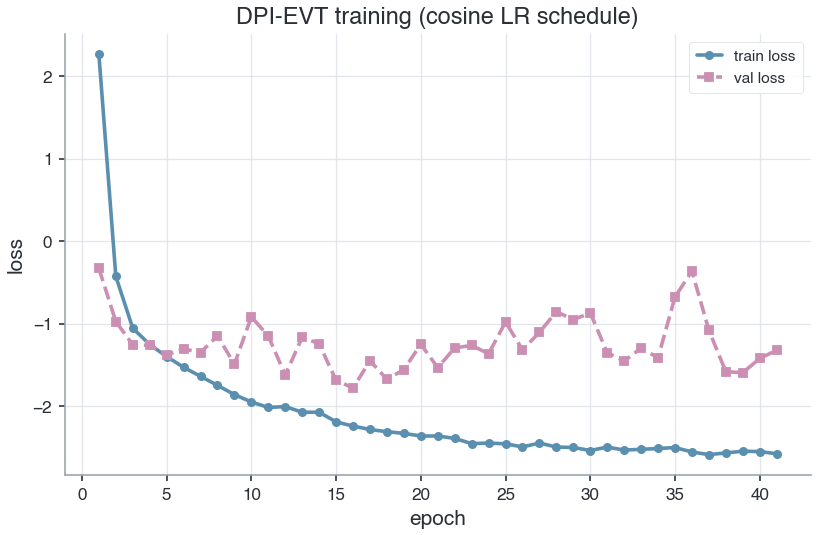

In [4]:
from liquefaction_ai.viz import new_figure, save_figure, QUALITATIVE, GRID
figw, fig = new_figure((7.4, 4.4)); ax = fig.add_subplot(111)
ax.plot(history["epoch"], history["train_loss"], "-o", color=QUALITATIVE[0], label="train loss", markersize=4)
ax.plot(history["epoch"], history["val_loss"], "--s", color="#CB8FB3", label="val loss", markersize=4)
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
if "val_AUROC" in history.columns:
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(history["epoch"], history["val_AUROC"], "-^", color="#7FB286", label="val AUROC", markersize=4)
    ax2.set_ylabel("val AUROC"); ax2.set_ylim(0.9, 1.0)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="center right")
else:
    ax.legend(fontsize=8.5)
ax.set_title("DPI-EVT training (cosine LR schedule)")
save_figure(figw, "2_4_dpi_evt_training", SAVE_FIGS)
figw

## Шаг 4. Калибровка интервалов и оценка на тесте

`fit_interval_scale` подбирает масштаб ширины интервалов по валидации (целевое покрытие 90 %).
Затем считаем полный набор метрик на тестовой выборке.

In [5]:
calib_scale = fit_interval_scale(model, val, config, device, level=0.90)
metrics, _ = compute_metrics("DPI-EVT", collect_outputs(model, test, config, device), test, config)
keys = [("PPR Traj_RMSE", "Traj_RMSE"), ("Traj CRPS", "Traj_CRPS"), ("Calibration err", "Calibration_Error"),
        ("AUROC", "AUROC"), ("Brier", "Brier"), ("Physics violation", "Physics_Violation_Rate"),
        ("N_liq logMAE", "N_liq_logMAE"), ("N_liq MAE", "N_liq_MAE"), ("CRR RMSE", "CRR_RMSE")]
display(pd.DataFrame({"Metric": [k for k, _ in keys],
                      "DPI-EVT": [round(float(metrics[v]), 4) if metrics[v] == metrics[v] else None for _, v in keys]}))
print("calib_scale:", round(float(calib_scale), 3))

,Metric,DPI-EVT
0,PPR Traj_RMSE,0.1052
1,Traj CRPS,0.0546
2,Calibration err,0.0097
3,AUROC,0.9935
4,Brier,0.0219
5,Physics violation,0.0000
6,N_liq logMAE,0.8386
7,N_liq MAE,289.9166
8,CRR RMSE,0.1903


calib_scale: 1.4


## Шаг 5. Сохранение модели

Сохраняем веса, гиперпараметры (с `calib_scale`) и историю — в том же формате, что и остальные
модели, поэтому ноутбуки оценки серии 3 подхватывают DPI-EVT автоматически.

In [6]:
hp = {"model_type": "DPIEvtNet", "display_name": "DPI-EVT", "model_kwargs": model_kwargs,
      "search": {"grid": grid, "score_metric": SELECTION_METRIC, "best": best}}
write_hyperparams(MODELS_DIR, "dpi_evt", hp)
save_trained_model(model, MODELS_DIR, "dpi_evt", {**hp, "epochs": len(history), "calib_scale": float(calib_scale)}, history)
print("DPI-EVT сохранён в", MODELS_DIR / "dpi_evt")

DPI-EVT сохранён в /Users/nikita/Desktop/projects/liquefaction-ai/models/dpi_evt


## Итог

DPI-EVT обучен штатно (косинусный LR, развязанная CRR, N_liq из кривой), откалиброван и
сохранён в `models/dpi_evt`. Теперь он воспроизводимо входит в пайплайн: после `2_1`–`2_3`
запустите этот ноутбук — и серия `3_*` оценит полный набор моделей, включая DPI-EVT, по
единому grouped/site-heldout протоколу.

Запускать после смены датасета (ноутбук `1_0`) или при пустой папке `models/`.
